In [1]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import json
import ast
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import seaborn as sns
import numpy as np
from scipy.optimize import curve_fit
from tqdm import tqdm
from tqdm.auto import tqdm
tqdm.pandas()
import os
import math
import psutil
import gc
import chess
import chess.engine
import chess.svg
from IPython.display import display, HTML
import subprocess
import time
from pathlib import Path
import matplotlib.gridspec as gridspec
import matplotlib.image as mpimg
import matplotlib.patches as patches
import sqlite3
from matplotlib.patches import ConnectionPatch, Rectangle
from functools import reduce
import lightgbm as lgb
import shap
from sklearn.metrics import mean_absolute_error, mean_squared_error

df=pd.read_parquet('skill-elo.parquet')

In [3]:
df = df.sort_values(['Player', 'Week_Idx']).reset_index(drop=True)
df.head()

,Player,Week_Idx,Is_Optimal,Δi,Is_Blunder,Is_Error,Cog_Speed,move_count,Time_Management_Score,Start_ELO,End_ELO,Games_This_Week,ELO_Change
0,4empechement,63,0.500000,77.541832,0.043825,0.087649,0.433976,502,-0.531818,2490,2485,11,-5
1,4empechement,70,0.520792,128.621780,0.037624,0.081188,0.458203,505,-0.020909,2473,2373,11,-100
2,4empechement,71,0.645652,74.480438,0.028261,0.043478,0.461216,460,-0.116364,2366,2354,11,-12
3,4empechement,77,0.536585,77.416855,0.031042,0.066519,0.434357,451,-0.389091,2368,2385,11,17
4,4empechement,80,0.567500,113.712502,0.042500,0.070000,0.445507,400,-0.508182,2405,2410,11,5


## LGB

In [4]:
features = [
    'Is_Optimal', 'Is_Blunder', 'Is_Error', 'Cog_Speed', 
    # 'move_count', 'Games_This_Week', 'Δi'
    'Time_Management_Score', 'Start_ELO'
]
target = 'ELO_Change'

# 3. 按时间轴切分数据集 (Out-of-Time Validation)
# 找出全局的时间分位数，比如前 80% 的周作为训练集，后 20% 的周作为测试集
split_point = df['Week_Idx'].quantile(0.8)

train_data = df[df['Week_Idx'] <= split_point]
test_data = df[df['Week_Idx'] > split_point]

X_train, y_train = train_data[features], train_data[target]
X_test, y_test = test_data[features], test_data[target]

print(f"训练集大小: {X_train.shape}, 测试集大小: {X_test.shape}")


from lightgbm import early_stopping
# 加入验证集早停，防止过拟合，自动找最优树数量
model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=63,
    reg_alpha=0.1, reg_lambda=0.2, # L1L2正则，压制过拟合
    random_state=42,
    n_jobs=-1
)
# 用训练集内部时序验证早停
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], callbacks=[early_stopping(50)])

训练集大小: (139406, 6), 测试集大小: (34363, 6)
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000953 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 139406, number of used features: 6
[LightGBM] [Info] Start training from score 1.237780
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[65]	valid_0's l2: 636.031


,boosting_type,'gbdt'
,num_leaves,63
,max_depth,-1
,learning_rate,0.03
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20



【模型评估结果】
平均绝对误差 (MAE): 17.31 分
瞎猜的 RMSE: 25.88
模型的 RMSE: 25.22
R平方值 (R2 Score): 0.0503


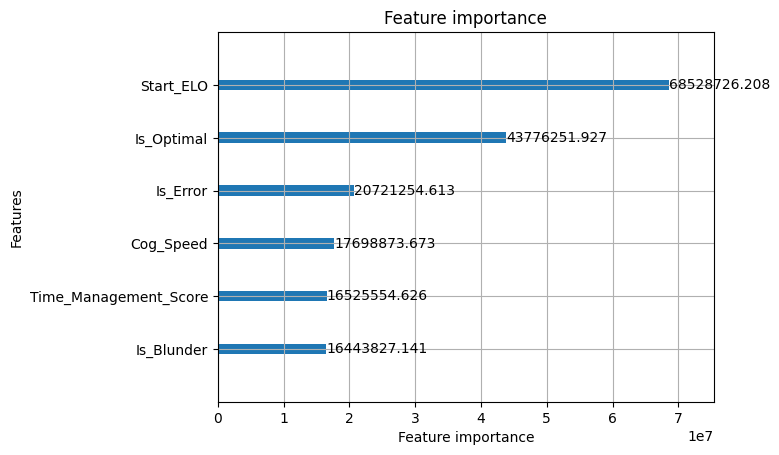

In [5]:
# 5. 模型预测与评估
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\n【模型评估结果】")
print(f"平均绝对误差 (MAE): {mae:.2f} 分")

from sklearn.dummy import DummyRegressor
from sklearn.metrics import r2_score

# 建立一个最蠢的模型：永远只预测训练集的目标均值
dummy_regr = DummyRegressor(strategy="mean")
dummy_regr.fit(X_train, y_train)
dummy_pred = dummy_regr.predict(X_test)

dummy_rmse = np.sqrt(mean_squared_error(y_test, dummy_pred))
r2 = r2_score(y_test, y_pred)

print(f"瞎猜的 RMSE: {dummy_rmse:.2f}")
print(f"模型的 RMSE: {rmse:.2f}")
print(f"R平方值 (R2 Score): {r2:.4f}")

# (可选) 查看最基础的特征重要性
lgb.plot_importance(model, max_num_features=10, importance_type='gain')
plt.show()

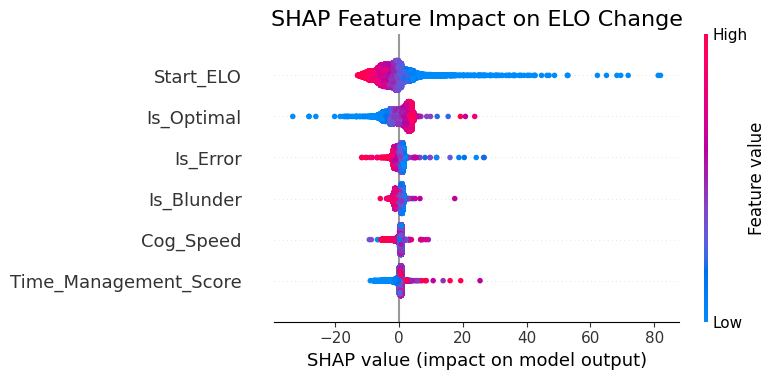

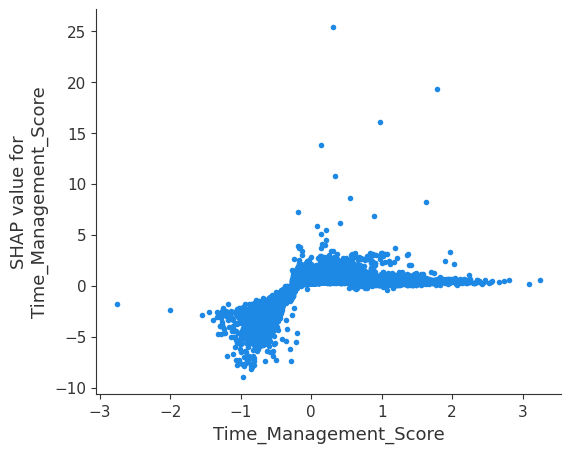

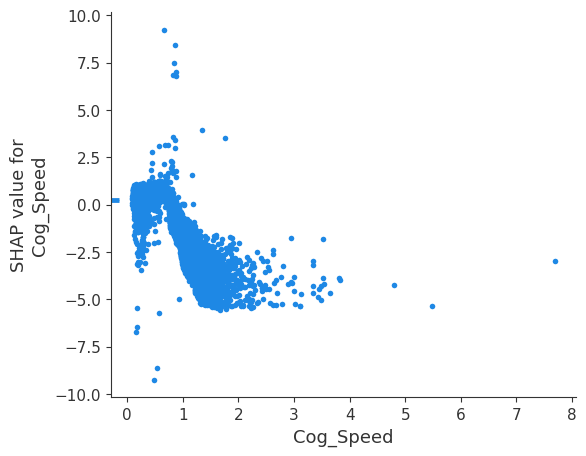

In [6]:
# 1. 训练好你的模型后，把模型和训练数据喂给 SHAP
# 注意：用 X_test 解释可以看模型在未知数据上的表现，如果数据太大可以 sample 几千行
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# 2. 画出最经典的 SHAP 蜂群图 (Beeswarm Summary Plot)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Feature Impact on ELO Change", fontsize=16)
plt.tight_layout()
plt.show()

# 3. 针对你的得意之作画偏倚图 (Dependence Plot)
# 看看 Time_Management_Score 具体是怎么影响涨跌的，它会不会是非线性的？
shap.dependence_plot("Time_Management_Score", shap_values, X_test, interaction_index=None)
shap.dependence_plot("Cog_Speed", shap_values, X_test, interaction_index=None)

测试集涨分比例: 0.48342694176876294
[LightGBM] [Info] Number of positive: 68138, number of negative: 71268
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000755 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 139406, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.488774 -> initscore=-0.044912
[LightGBM] [Info] Start training from score -0.044912
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[85]	valid_0's binary_logloss: 0.672612

【分类模型评估结果】
准确率 (Accuracy): 0.5841
AUC Score: 0.6163

详细分类报告:
              precision    recall  f1-score   support

           0       0.58      0.72      0.64     17751
           1       0.59      0.44      0.51     16612

    accuracy                           0.58     34363
   macro avg       0.59      0.58      0.57     34363
weighte

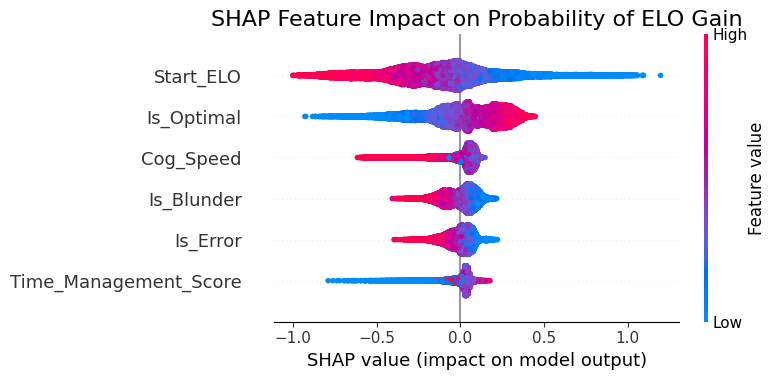

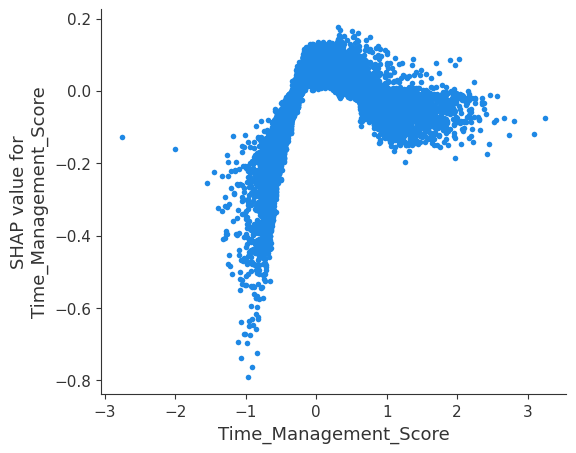

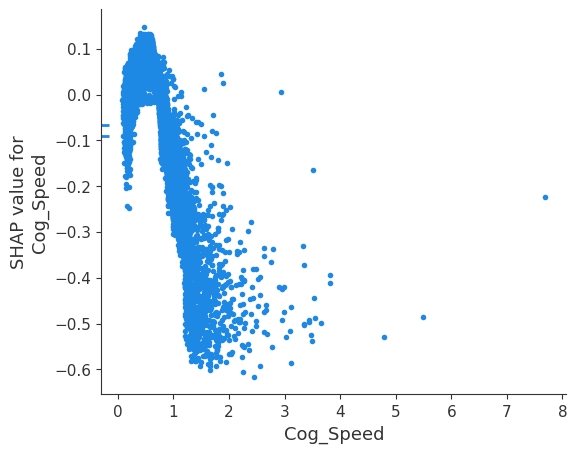

In [ ]:
from lightgbm import early_stopping
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
import warnings
warnings.filterwarnings('ignore') # 忽略一些版本警告

# 1. 目标变量降维：将连续涨跌转化为二分类 (1: 涨分, 0: 没涨或掉分)
# 注意避免 SettingWithCopyWarning，使用 .loc 或直接基于原条件赋值
train_data_clf = train_data.copy()
test_data_clf = test_data.copy()

train_data_clf['Is_Improve'] = (train_data_clf['ELO_Change'] > 0).astype(int)
test_data_clf['Is_Improve'] = (test_data_clf['ELO_Change'] > 0).astype(int)

y_train_clf = train_data_clf['Is_Improve']
y_test_clf = test_data_clf['Is_Improve']

# 查看正负样本比例 (看看大家是不是掉分的多)
print("测试集涨分比例:", y_test_clf.mean())

# 2. 训练 LightGBM 分类器
clf = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=63,
    reg_alpha=0.1, reg_lambda=0.2,
    random_state=42,
    n_jobs=-1
)

# 拟合分类器
clf.fit(X_train, y_train_clf, eval_set=[(X_test, y_test_clf)], callbacks=[early_stopping(50)])

# 3. 评估分类结果
y_pred_clf = clf.predict(X_test)
y_prob_clf = clf.predict_proba(X_test)[:, 1] # 提取判定为涨分(1)的概率

print("\n【分类模型评估结果】")
print(f"准确率 (Accuracy): {accuracy_score(y_test_clf, y_pred_clf):.4f}")
print(f"AUC Score: {roc_auc_score(y_test_clf, y_prob_clf):.4f}")
print("\n详细分类报告:")
print(classification_report(y_test_clf, y_pred_clf))


# 注意：分类器的 TreeExplainer 输出会有所不同，通常是个 list
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test)

# 对于 LightGBM 二分类，shap_values 可能是一个列表 [预测0的SHAP, 预测1的SHAP]
# 我们只关心预测为 1 (涨分) 的解释，所以取 shap_values[1]
# 如果跑出来报错说 shap_values 不是 list，那就直接用 shap_values
if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]
else:
    shap_values_to_plot = shap_values

# 1. 蜂群图
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_to_plot, X_test, show=False)
plt.title("SHAP Feature Impact on Probability of ELO Gain", fontsize=16)
plt.tight_layout()
plt.show()

# 2. 偏倚图
shap.dependence_plot("Time_Management_Score", shap_values_to_plot, X_test, interaction_index=None)
shap.dependence_plot("Cog_Speed", shap_values_to_plot, X_test, interaction_index=None)

In [10]:
%pip install optuna

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import optuna
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

# 假设你的 X_train, y_train_clf, X_test, y_test_clf 已经准备好了
# 为了避免过拟合，我们从训练集中再切出一小块作为验证集给 Optuna 用
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train_clf, test_size=0.2, random_state=42)

def objective(trial):
    # 定义超参数的搜索空间
    param = {
        'objective': 'binary',
        'metric': 'auc',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 200),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'random_state': 42,
        'n_jobs': -1
    }

    # 训练模型
    gbm = lgb.LGBMClassifier(**param)
    
    # 拟合时使用 early_stopping
    gbm.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)]
    )

    # 预测概率计算 AUC
    preds = gbm.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, preds)
    return auc

# 创建一个求最大化 (maximize) AUC 的黑盒优化研究
study = optuna.create_study(direction='maximize')
print("开始 Optuna 自动化参数搜索...")
# n_trials=50 代表试 50 种不同的参数组合，大概需要几分钟
study.optimize(objective, n_trials=50)

print("\n【搜索结束】")
print('最佳验证集 AUC:', study.best_value)
print('最佳参数组合:')
for key, value in study.best_trial.params.items():
    print(f"    '{key}': {value},")

[I 2026-04-19 19:06:18,407] A new study created in memory with name: no-name-502c1a18-2822-4324-87a7-2c7840bfc94c


开始 Optuna 自动化参数搜索...


[I 2026-04-19 19:06:19,296] Trial 0 finished with value: 0.6300005777721902 and parameters: {'n_estimators': 529, 'learning_rate': 0.00601390830507452, 'num_leaves': 116, 'max_depth': 5, 'min_child_samples': 100, 'reg_alpha': 0.00015095969733421098, 'reg_lambda': 3.093746355053349, 'subsample': 0.7302432073082318, 'colsample_bytree': 0.6142947029908781}. Best is trial 0 with value: 0.6300005777721902.
[I 2026-04-19 19:06:19,809] Trial 1 finished with value: 0.6307918400036854 and parameters: {'n_estimators': 251, 'learning_rate': 0.015868066272290208, 'num_leaves': 38, 'max_depth': 9, 'min_child_samples': 129, 'reg_alpha': 1.1213706440190039e-07, 'reg_lambda': 0.17068034607948315, 'subsample': 0.5138454870116433, 'colsample_bytree': 0.6580228539791347}. Best is trial 1 with value: 0.6307918400036854.
[I 2026-04-19 19:06:20,633] Trial 2 finished with value: 0.6298719185858503 and parameters: {'n_estimators': 919, 'learning_rate': 0.012234387203653564, 'num_leaves': 92, 'max_depth': 11, 


【搜索结束】
最佳验证集 AUC: 0.6318203388421574
最佳参数组合:
    'n_estimators': 476,
    'learning_rate': 0.06634921385561973,
    'num_leaves': 75,
    'max_depth': 3,
    'min_child_samples': 144,
    'reg_alpha': 0.24856730059038104,
    'reg_lambda': 4.36389427555464e-08,
    'subsample': 0.7665518687452515,
    'colsample_bytree': 0.9443801564447916,


In [ ]:
from lightgbm import LGBMClassifier, early_stopping
import warnings
warnings.filterwarnings('ignore')

# 【锁特征专用最优参数】特征完全不变，仅模型升级
clf = LGBMClassifier(
    n_estimators=476,
    learning_rate=0.06634921385561973,    # 更小学习率，细筛微弱信号
    num_leaves=75,         # 比原来大，捕捉非线性交互
    max_depth=3,
    reg_alpha=0.24856730059038104,
    reg_lambda=4.36389427555464e-08,
    subsample=0.7665518687452515,         # 行采样降噪
    colsample_bytree=0.9443801564447916,   # 列采样轻微防过拟合
    objective='binary',
    is_unbalance=False,
    random_state=42,
    n_jobs=-1
)

# 时序验证完全沿用你原来的切分
clf.fit(
    X_train, y_train_clf,
    eval_set=[(X_test, y_test_clf)],
    callbacks=[early_stopping(120)]
)

# 评估
y_pred_clf = clf.predict(X_test)
y_prob_clf = clf.predict_proba(X_test)[:, 1]

from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
print(f"AUC Score: {roc_auc_score(y_test_clf, y_prob_clf):.4f}")
print(f"Accuracy: {accuracy_score(y_test_clf, y_pred_clf):.4f}")
print(classification_report(y_test_clf, y_pred_clf))

Training until validation scores don't improve for 120 rounds
Early stopping, best iteration is:
[104]	valid_0's binary_logloss: 0.672735
AUC Score: 0.6161
Accuracy: 0.5846
              precision    recall  f1-score   support

           0       0.58      0.71      0.64     17751
           1       0.59      0.45      0.51     16612

    accuracy                           0.58     34363
   macro avg       0.59      0.58      0.57     34363
weighted avg       0.59      0.58      0.58     34363

